In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('tab10')

# Paths
RAW   = '../data/raw/'
PROC  = '../data/processed/'

print('Libraries loaded OK')

Libraries loaded OK


In [2]:
# ── Carrega os arquivos brutos ──────────────────────────────────────────────
df_train    = pd.read_csv(RAW + 'plfec-train-data.csv', sep=';')
df_weather  = pd.read_csv(RAW + 'plfec-weather.csv',    sep=';')
df_holidays = pd.read_csv(RAW + 'plfec-holidays.csv',   sep=';')
df_meta     = pd.read_csv(RAW + 'plfec-metadata.csv',   sep=';')

print('Dimensões dos datasets:')
print(f'  train-data : {df_train.shape}')
print(f'  weather    : {df_weather.shape}')
print(f'  holidays   : {df_holidays.shape}')
print(f'  metadata   : {df_meta.shape}')

Dimensões dos datasets:
  train-data : (6559830, 5)
  weather    : (3957035, 4)
  holidays   : (8387, 3)
  metadata   : (267, 11)


In [3]:
# ── Descrição dos campos ─────────────────────────────────────────────────────
print('=== df_train ===')
print(df_train.dtypes)
print(df_train.head(3))
print('\n=== df_weather ===')
print(df_weather.dtypes)
print(df_weather.head(3))
print('\n=== df_holidays ===')
print(df_holidays.dtypes)
print(df_holidays.head(3))
print('\n=== df_meta ===')
print(df_meta.dtypes)
print(df_meta.head(3))

=== df_train ===
obs_id          int64
SiteId          int64
Timestamp         str
ForecastId      int64
Value         float64
dtype: object
    obs_id  SiteId                  Timestamp  ForecastId         Value
0  4852050      42  2016-10-18T02:45:00+00:00        1087  26397.049623
1  1638923      42  2016-10-18T11:45:00+00:00        1087  42958.364641
2  5748910      42  2016-10-18T20:45:00+00:00        1087  27096.919666

=== df_weather ===
Timestamp          str
Temperature    float64
Distance       float64
SiteId           int64
dtype: object
                   Timestamp  Temperature   Distance  SiteId
0  2017-03-03T19:00:00+00:00         10.6  27.489346      51
1  2017-03-03T19:20:00+00:00         11.0  28.663082      51
2  2017-03-03T20:00:00+00:00          6.3  28.307039      51

=== df_holidays ===
Date         str
Holiday      str
SiteId     int64
dtype: object
         Date                Holiday  SiteId
0  2016-02-15  Washington's Birthday       1
1  2017-05-29           M

In [4]:
# ── Converte timestamps ──────────────────────────────────────────────────────
df_train['Timestamp']   = pd.to_datetime(df_train['Timestamp'])
df_weather['Timestamp'] = pd.to_datetime(df_weather['Timestamp'])

print('Período dos dados de energia:')
print(f'  Início : {df_train["Timestamp"].min()}')
print(f'  Fim    : {df_train["Timestamp"].max()}')
print(f'  Sites  : {df_train["SiteId"].nunique()} prédios')

Período dos dados de energia:
  Início : 2009-06-23 06:45:00+00:00
  Fim    : 2017-12-08 15:30:00+00:00
  Sites  : 267 prédios


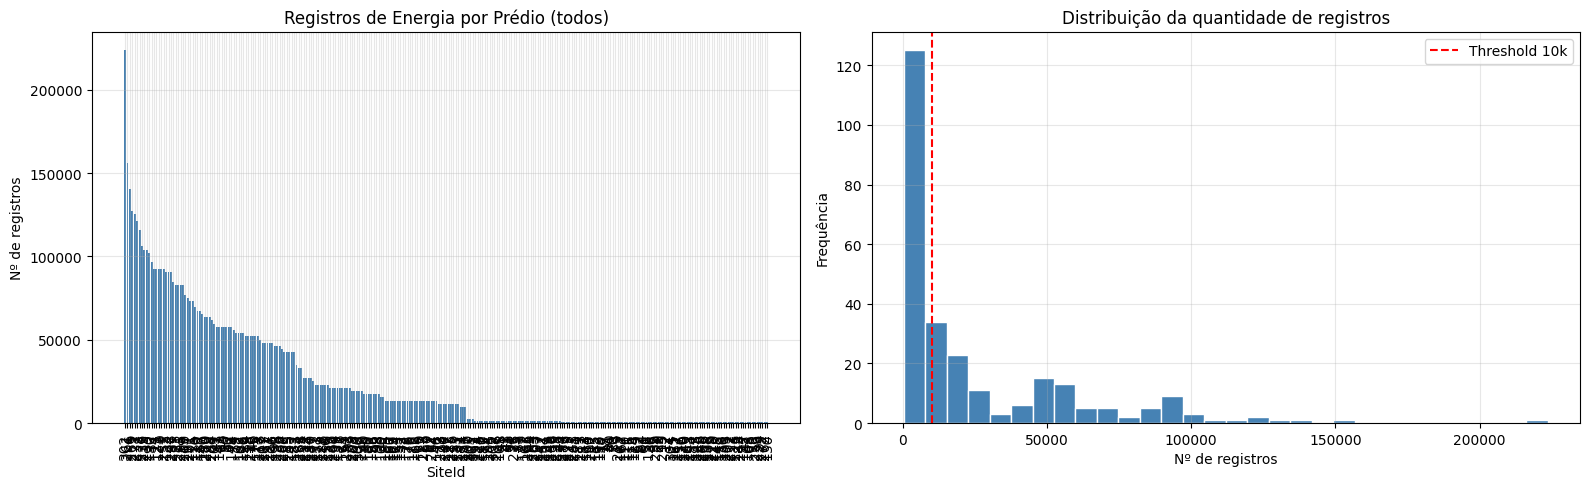

Prédios com mais de 10.000 registros: 139
Prédios com mais de 5.000 registros : 142


In [5]:
counts = df_train.groupby('SiteId').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barras — todos os prédios
axes[0].bar(counts.index.astype(str), counts.values, color='steelblue', width=0.8)
axes[0].set_xlabel('SiteId')
axes[0].set_ylabel('Nº de registros')
axes[0].set_title('Registros de Energia por Prédio (todos)')
axes[0].tick_params(axis='x', rotation=90)

# Histograma de distribuição
axes[1].hist(counts.values, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(10000, color='red', linestyle='--', label='Threshold 10k')
axes[1].set_xlabel('Nº de registros')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição da quantidade de registros')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Prédios com mais de 10.000 registros: {(counts > 10000).sum()}')
print(f'Prédios com mais de 5.000 registros : {(counts > 5000).sum()}')

In [6]:
# ── Seleciona prédios candidatos (>10k registros) ────────────────────────────
CANDIDATES = counts[counts > 10000].index.tolist()
print(f'Prédios selecionados (>10k registros): {CANDIDATES}')

# Estatísticas básicas por prédio candidato
df_cand = df_train[df_train['SiteId'].isin(CANDIDATES)].copy()
stats_df = df_cand.groupby('SiteId')['Value'].agg(['count','mean','std','min','max'])
stats_df.columns = ['N','Média (kWh)','Desvio Padrão','Min','Max']
stats_df = stats_df.round(2)
print('\nEstatísticas dos prédios candidatos:')
display(stats_df)

Prédios selecionados (>10k registros): [302, 261, 6, 269, 271, 237, 8, 276, 233, 235, 190, 33, 14, 123, 121, 9, 232, 122, 22, 298, 287, 25, 221, 295, 19, 200, 197, 201, 115, 120, 119, 87, 140, 280, 270, 88, 284, 109, 41, 141, 63, 49, 50, 62, 149, 74, 59, 162, 108, 126, 84, 178, 215, 46, 175, 173, 218, 107, 222, 191, 227, 106, 92, 228, 230, 204, 252, 89, 255, 143, 183, 2, 281, 268, 234, 212, 134, 250, 277, 151, 273, 129, 286, 16, 259, 135, 260, 294, 131, 26, 27, 154, 292, 93, 209, 203, 198, 300, 199, 40, 39, 180, 195, 86, 99, 98, 100, 42, 185, 160, 167, 169, 174, 153, 152, 73, 72, 76, 176, 186, 112, 66, 20, 117, 283, 60, 57, 267, 54, 146, 77, 223, 96, 247, 127, 285, 216, 53, 231]

Estatísticas dos prédios candidatos:


,N,Média (kWh),Desvio Padrão,Min,Max
SiteId,,,,,
2,34486,67591.69,54961.98,12558.21,306452.81
6,139716,27682.73,10620.03,13341.72,71063.18
8,114962,37891.42,18922.37,0.00,98200.96
9,91926,3075.19,1885.24,198.54,14484.85
14,91676,32619.19,7890.22,7353.17,62284.36
...,...,...,...,...,...
294,20291,37029.51,25010.03,0.00,157095.37
295,79381,27118.18,18546.26,0.00,125020.55
298,90188,9895.34,19577.64,428.93,4872706.06


In [7]:
SITE = 40
df40 = df_train[df_train['SiteId'] == SITE].copy().sort_values('Timestamp').reset_index(drop=True)

print(f'SiteId {SITE}:')
print(f'  Registros : {len(df40)}')
print(f'  Início    : {df40["Timestamp"].min()}')
print(f'  Fim       : {df40["Timestamp"].max()}')
print(f'  Consumo médio: {df40["Value"].mean():.2f} kWh')
print(f'  Consumo std  : {df40["Value"].std():.2f} kWh')

SiteId 40:
  Registros : 17352
  Início    : 2015-07-03 14:30:00+00:00
  Fim       : 2017-11-08 13:30:00+00:00
  Consumo médio: 5476.04 kWh
  Consumo std  : 3950.01 kWh


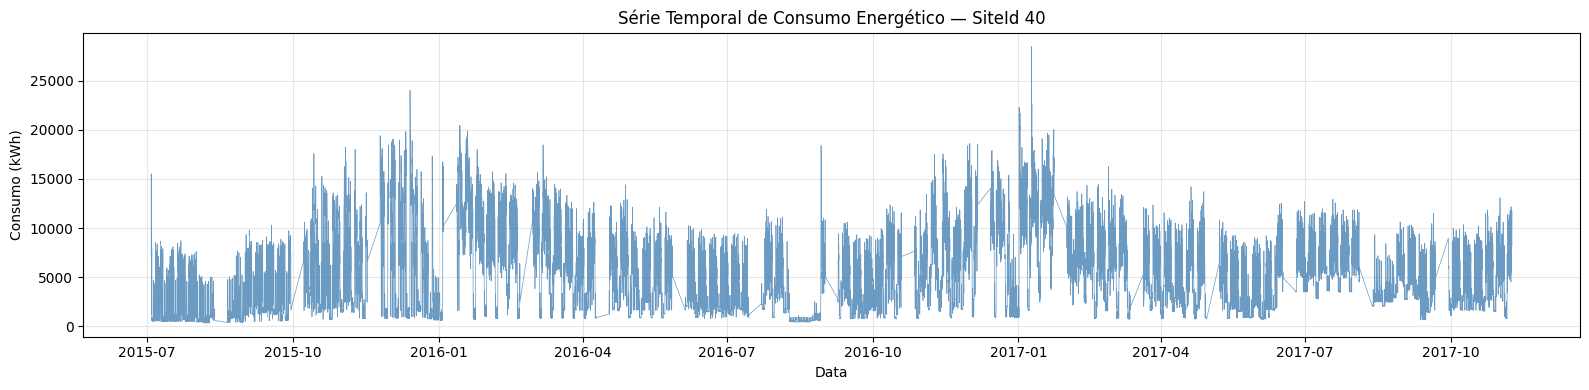

In [8]:
# ── Série temporal completa ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df40['Timestamp'], df40['Value'], linewidth=0.5, alpha=0.8, color='steelblue')
ax.set_title(f'Série Temporal de Consumo Energético — SiteId {SITE}')
ax.set_xlabel('Data')
ax.set_ylabel('Consumo (kWh)')
plt.tight_layout()
plt.show()

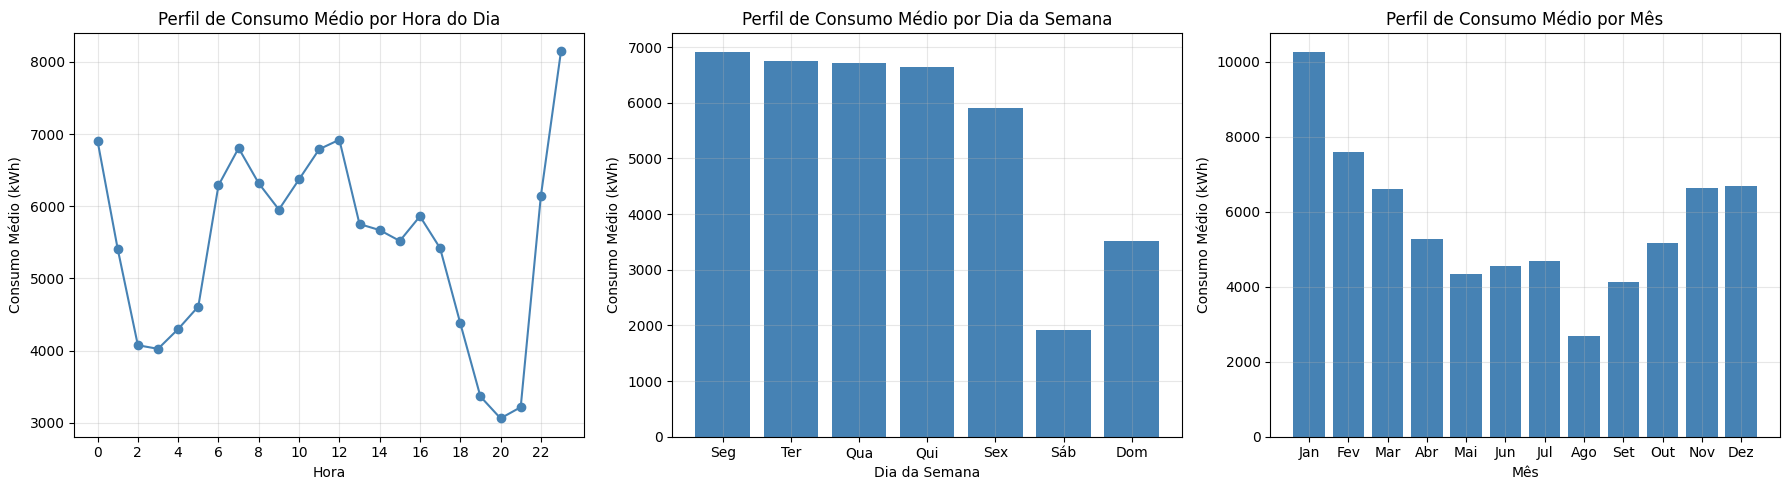

In [9]:
# ── Extrai features de tempo ─────────────────────────────────────────────────
df40['hour']       = df40['Timestamp'].dt.hour
df40['dayofweek']  = df40['Timestamp'].dt.dayofweek   # 0=Seg, 6=Dom
df40['month']      = df40['Timestamp'].dt.month
df40['is_weekend'] = df40['dayofweek'].isin([5, 6]).astype(int)

# Padrão diário
hourly = df40.groupby('hour')['Value'].mean()

# Padrão semanal
daily  = df40.groupby('dayofweek')['Value'].mean()
day_names = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']

# Padrão mensal
monthly = df40.groupby('month')['Value'].mean()
month_names = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(hourly.index, hourly.values, marker='o', color='steelblue')
axes[0].set_title('Perfil de Consumo Médio por Hora do Dia')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Consumo Médio (kWh)')
axes[0].set_xticks(range(0, 24, 2))

axes[1].bar(range(7), daily.values, color='steelblue', tick_label=day_names)
axes[1].set_title('Perfil de Consumo Médio por Dia da Semana')
axes[1].set_xlabel('Dia da Semana')
axes[1].set_ylabel('Consumo Médio (kWh)')

axes[2].bar(range(1, 13), monthly.values, color='steelblue', tick_label=month_names)
axes[2].set_title('Perfil de Consumo Médio por Mês')
axes[2].set_xlabel('Mês')
axes[2].set_ylabel('Consumo Médio (kWh)')

plt.tight_layout()
plt.show()

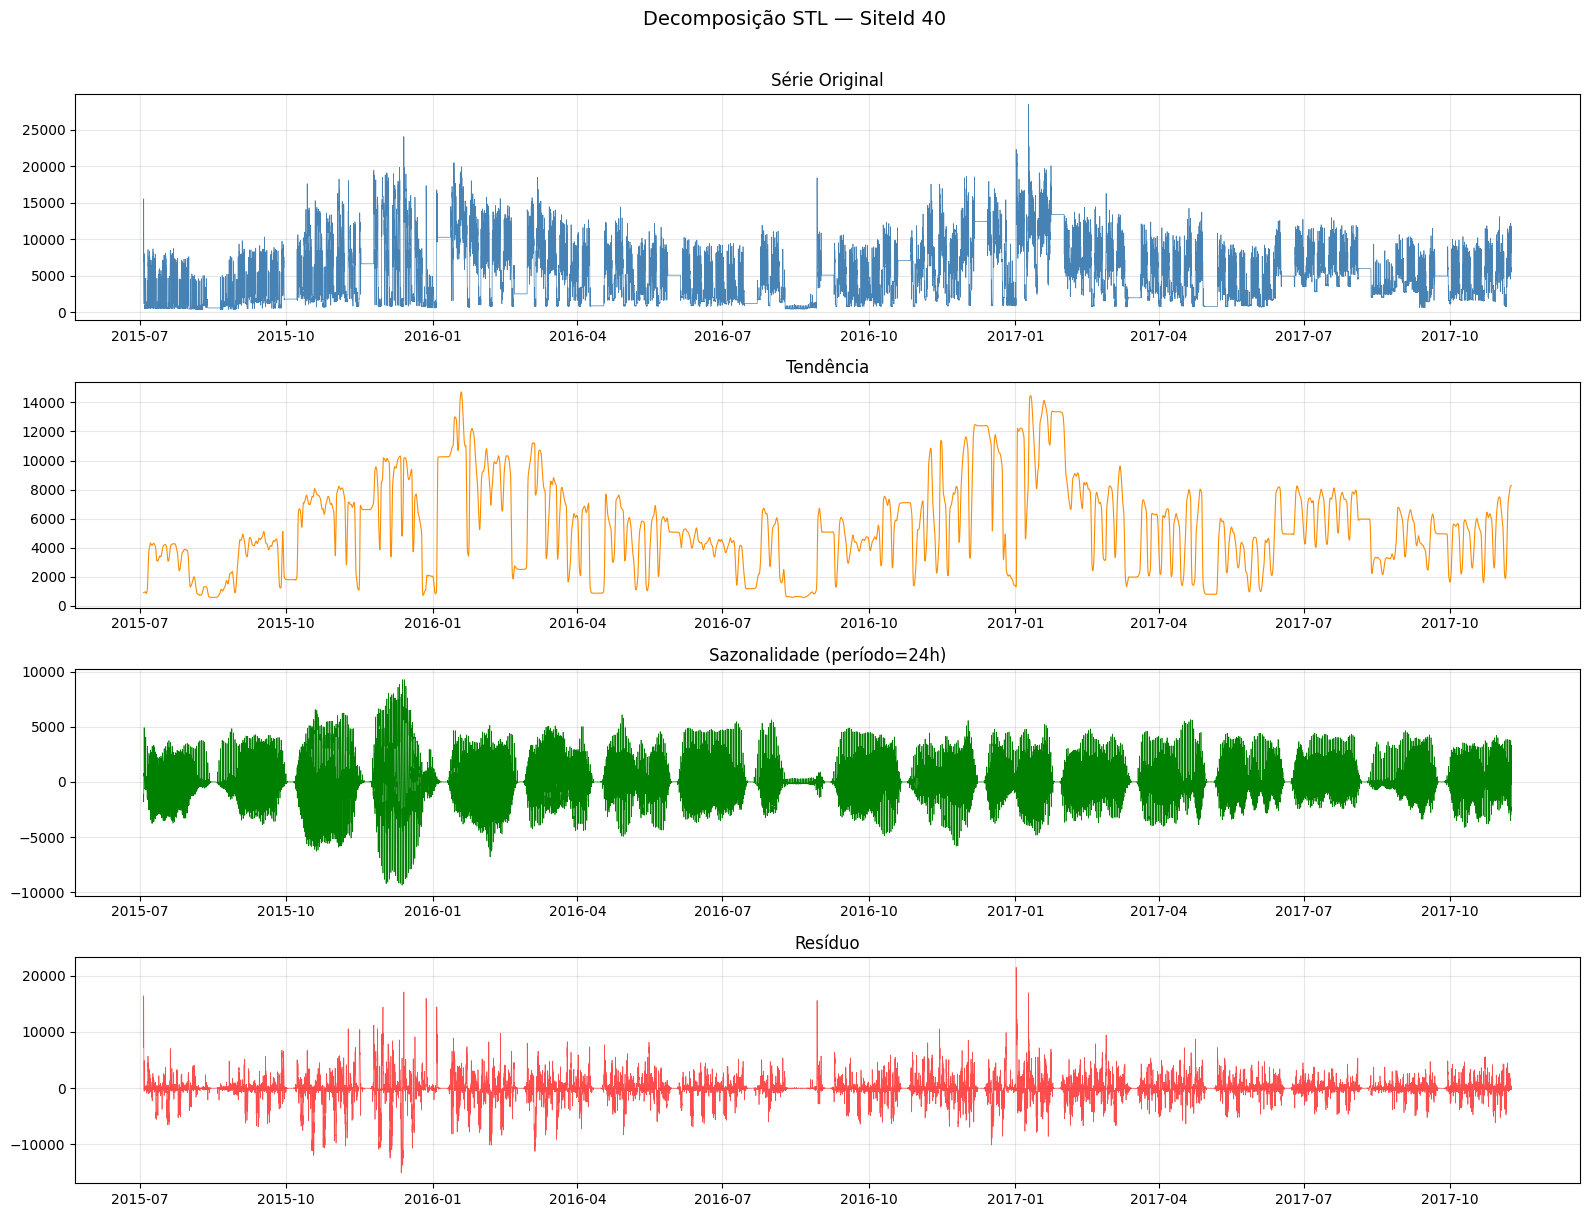

In [10]:
# Resamplea para frequência horária regular (mediana por hora)
df40_hourly = df40.set_index('Timestamp')['Value'].resample('1h').median().ffill()

# STL com período de 24h (sazonalidade diária)
stl = STL(df40_hourly, period=24, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
axes[0].plot(df40_hourly.index, df40_hourly.values, linewidth=0.5, color='steelblue')
axes[0].set_title('Série Original')
axes[1].plot(result.trend.index, result.trend.values, linewidth=0.8, color='darkorange')
axes[1].set_title('Tendência')
axes[2].plot(result.seasonal.index, result.seasonal.values, linewidth=0.5, color='green')
axes[2].set_title('Sazonalidade (período=24h)')
axes[3].plot(result.resid.index, result.resid.values, linewidth=0.5, color='red', alpha=0.7)
axes[3].set_title('Resíduo')
for ax in axes:
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3)
plt.suptitle(f'Decomposição STL — SiteId {SITE}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

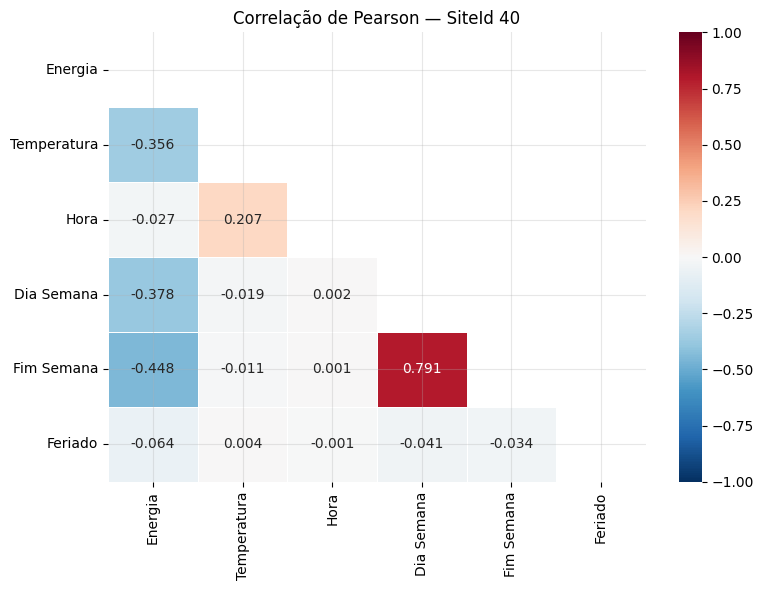

Correlações com Energia:
Fim Semana    -0.447600
Dia Semana    -0.377915
Temperatura   -0.356072
Feriado       -0.064320
Hora          -0.027284


In [11]:
# ── Cruza energia com temperatura para SiteId 40 ─────────────────────────────
# Usa a menor distância ao prédio (mesma abordagem do TCC2)
df_w40 = df_weather[df_weather['SiteId'] == SITE].copy()
df_w40['Timestamp'] = pd.to_datetime(df_w40['Timestamp'])
df_w40 = df_w40.sort_values(['Timestamp', 'Distance']).drop_duplicates(subset='Timestamp', keep='first')

df_merged = pd.merge(df40, df_w40[['Timestamp', 'Temperature']], on='Timestamp', how='inner')
df_merged['hour_num'] = df_merged['hour']

# Adiciona feriados
df_hol = df_holidays[df_holidays['SiteId'] == SITE].copy()
df_hol['Date'] = pd.to_datetime(df_hol['Date']).dt.date
df_merged['date'] = df_merged['Timestamp'].dt.date
df_merged['is_holiday'] = df_merged['date'].isin(df_hol['Date']).astype(int)

corr_cols = ['Value', 'Temperature', 'hour_num', 'dayofweek', 'is_weekend', 'is_holiday']
corr_labels = ['Energia', 'Temperatura', 'Hora', 'Dia Semana', 'Fim Semana', 'Feriado']
corr_matrix = df_merged[corr_cols].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, mask=mask, linewidths=0.5)
ax.set_title(f'Correlação de Pearson — SiteId {SITE}')
plt.tight_layout()
plt.show()

print('Correlações com Energia:')
print(corr_matrix['Energia'].drop('Energia').sort_values(key=abs, ascending=False).to_string())

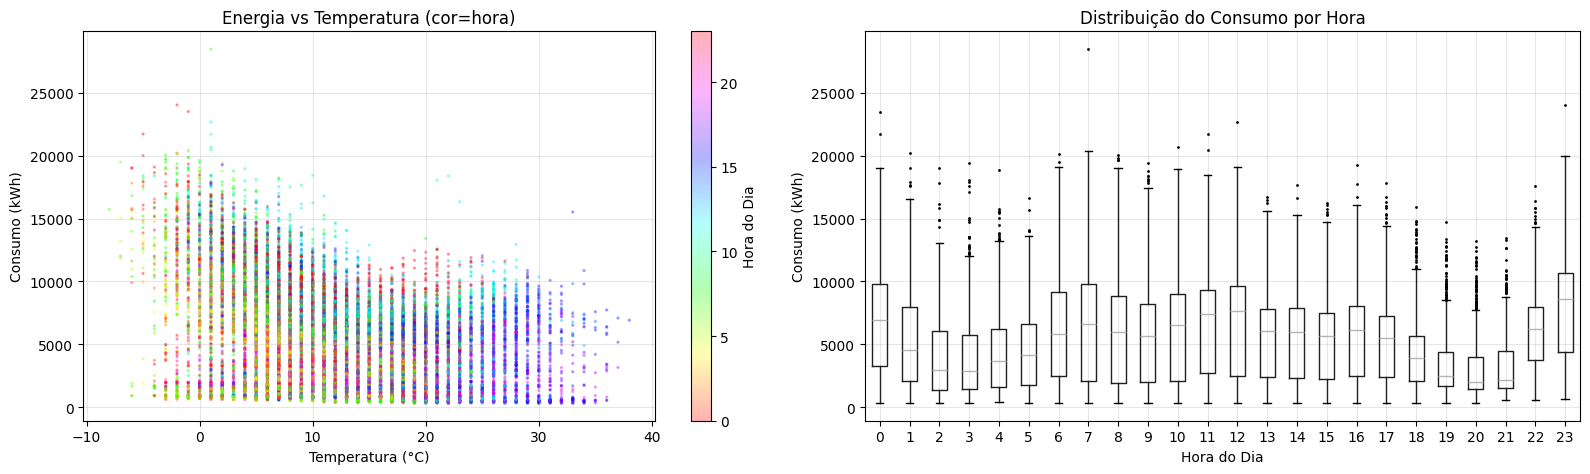

In [12]:
# ── Scatter: Energia vs Temperatura colorido por hora ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sc = axes[0].scatter(df_merged['Temperature'], df_merged['Value'],
                     c=df_merged['hour'], cmap='hsv', alpha=0.3, s=2)
plt.colorbar(sc, ax=axes[0], label='Hora do Dia')
axes[0].set_xlabel('Temperatura (°C)')
axes[0].set_ylabel('Consumo (kWh)')
axes[0].set_title('Energia vs Temperatura (cor=hora)')

# Boxplot por hora
df_merged.boxplot(column='Value', by='hour', ax=axes[1], flierprops=dict(markersize=1))
axes[1].set_title('Distribuição do Consumo por Hora')
axes[1].set_xlabel('Hora do Dia')
axes[1].set_ylabel('Consumo (kWh)')
plt.suptitle('')

plt.tight_layout()
plt.show()

Outliers por IQR  : 116 (0.7%)
Outliers por Z>3  : 0 (0.0%)


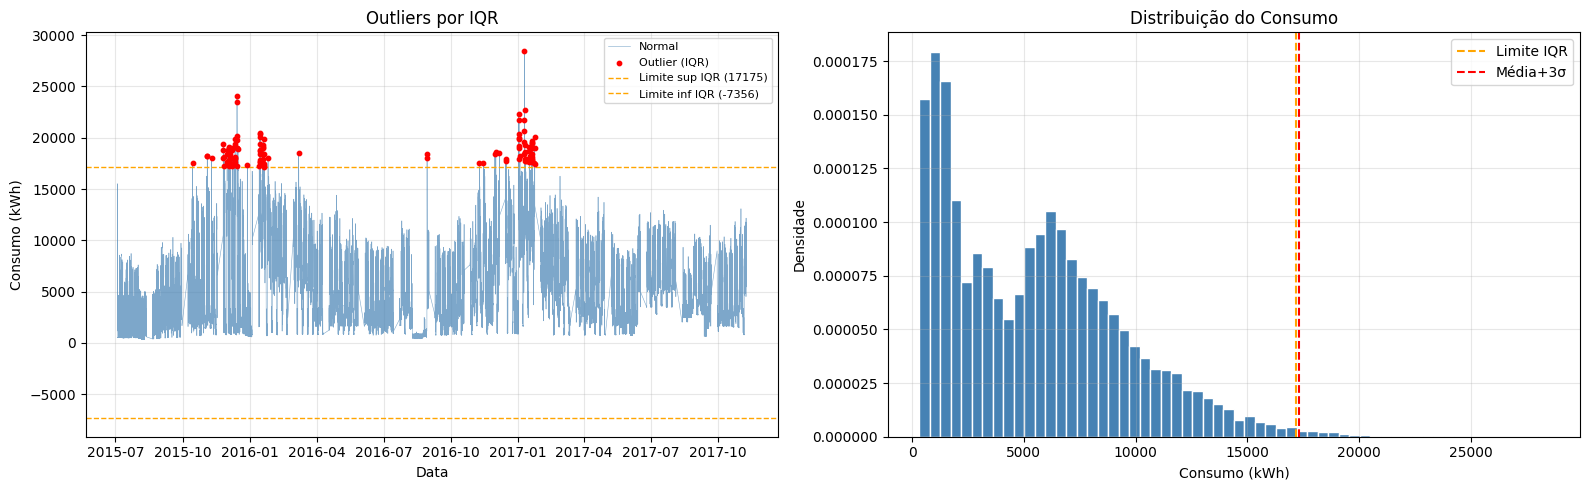

In [13]:
# ── IQR ──────────────────────────────────────────────────────────────────────
Q1 = df40['Value'].quantile(0.25)
Q3 = df40['Value'].quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR
outliers_iqr = df40[(df40['Value'] < lower_iqr) | (df40['Value'] > upper_iqr)]

# ── Z-score ───────────────────────────────────────────────────────────────────
df40['z_score'] = np.abs(stats.zscore(df40['Value']))
outliers_z = df40[df40['z_score'] > 3]

print(f'Outliers por IQR  : {len(outliers_iqr)} ({100*len(outliers_iqr)/len(df40):.1f}%)')
print(f'Outliers por Z>3  : {len(outliers_z)} ({100*len(outliers_z)/len(df40):.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(df40['Timestamp'], df40['Value'], linewidth=0.4, color='steelblue', alpha=0.7, label='Normal')
axes[0].scatter(outliers_iqr['Timestamp'], outliers_iqr['Value'],
                color='red', s=10, zorder=5, label='Outlier (IQR)')
axes[0].axhline(upper_iqr, color='orange', linestyle='--', linewidth=1, label=f'Limite sup IQR ({upper_iqr:.0f})')
axes[0].axhline(lower_iqr, color='orange', linestyle='--', linewidth=1, label=f'Limite inf IQR ({lower_iqr:.0f})')
axes[0].set_title('Outliers por IQR')
axes[0].set_xlabel('Data')
axes[0].set_ylabel('Consumo (kWh)')
axes[0].legend(fontsize=8)

axes[1].hist(df40['Value'], bins=60, color='steelblue', edgecolor='white', density=True)
axes[1].axvline(upper_iqr, color='orange', linestyle='--', label='Limite IQR')
axes[1].axvline(df40['Value'].mean() + 3*df40['Value'].std(), color='red', linestyle='--', label='Média+3σ')
axes[1].set_title('Distribuição do Consumo')
axes[1].set_xlabel('Consumo (kWh)')
axes[1].set_ylabel('Densidade')
axes[1].legend()

plt.tight_layout()
plt.show()

Intervalo entre medições (horas):
count    17351.00
mean         1.19
std          6.01
min          1.00
25%          1.00
50%          1.00
75%          1.00
max        193.00
Name: delta, dtype: float64

Gaps > 2h: 17
                     Timestamp  delta
964  2015-08-20 18:30:00+00:00  193.0
1928 2015-10-07 22:30:00+00:00  193.0
2892 2015-11-25 02:30:00+00:00  193.0
3856 2016-01-12 06:30:00+00:00  193.0
4820 2016-02-29 10:30:00+00:00  193.0
5784 2016-04-17 14:30:00+00:00  193.0
6748 2016-06-04 18:30:00+00:00  193.0
7712 2016-07-22 22:30:00+00:00  193.0
8676 2016-09-09 02:30:00+00:00  193.0
9640 2016-10-27 06:30:00+00:00  193.0


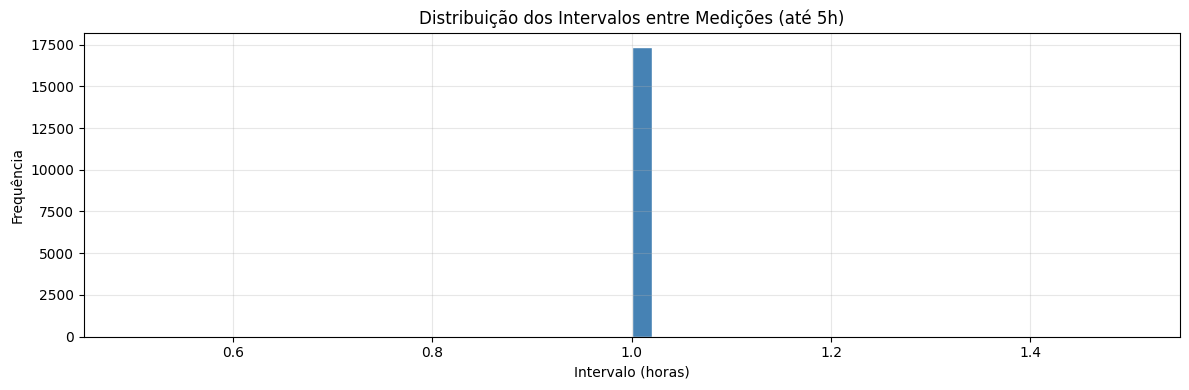

In [14]:
# ── Analisa intervalos entre medições ────────────────────────────────────────
df40_sorted = df40.sort_values('Timestamp').copy()
df40_sorted['delta'] = df40_sorted['Timestamp'].diff().dt.total_seconds() / 3600  # horas

print('Intervalo entre medições (horas):')
print(df40_sorted['delta'].describe().round(2))

gaps = df40_sorted[df40_sorted['delta'] > 2]
print(f'\nGaps > 2h: {len(gaps)}')
if len(gaps) > 0:
    print(gaps[['Timestamp','delta']].head(10).to_string())

# Histograma dos intervalos
fig, ax = plt.subplots(figsize=(12, 4))
normal_deltas = df40_sorted[df40_sorted['delta'] <= 5]['delta']
ax.hist(normal_deltas, bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribuição dos Intervalos entre Medições (até 5h)')
ax.set_xlabel('Intervalo (horas)')
ax.set_ylabel('Frequência')
plt.tight_layout()
plt.show()

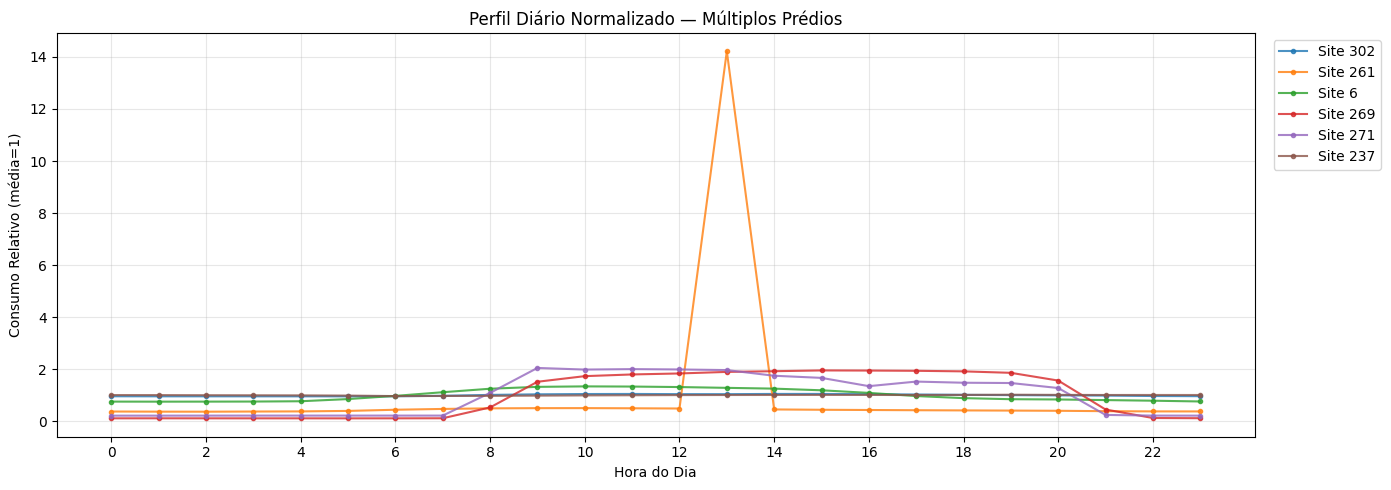

In [15]:
# ── Comparação de múltiplos prédios: padrão diário ───────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

for site in CANDIDATES[:6]:  # máx 6 prédios para legibilidade
    df_site = df_train[df_train['SiteId'] == site].copy()
    df_site['hour'] = pd.to_datetime(df_site['Timestamp']).dt.hour
    hourly_profile = df_site.groupby('hour')['Value'].mean()
    # Normaliza para comparação relativa
    hourly_norm = hourly_profile / hourly_profile.mean()
    ax.plot(hourly_norm.index, hourly_norm.values, marker='o', markersize=3,
            label=f'Site {site}', alpha=0.8)

ax.set_title('Perfil Diário Normalizado — Múltiplos Prédios')
ax.set_xlabel('Hora do Dia')
ax.set_ylabel('Consumo Relativo (média=1)')
ax.set_xticks(range(0, 24, 2))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [16]:
# ── Salva o dataframe mesclado (base para notebooks seguintes) ───────────────
df_merged_clean = df_merged.drop(columns=['z_score', 'date'], errors='ignore')
df_merged_clean.to_csv(PROC + 'df_site40_merged.csv', index=False)
print(f'Salvo: {PROC}df_site40_merged.csv — shape: {df_merged_clean.shape}')
df_merged_clean.head(3)

Salvo: ../data/processed/df_site40_merged.csv — shape: (16995, 12)


,obs_id,SiteId,Timestamp,ForecastId,Value,hour,dayofweek,month,is_weekend,Temperature,hour_num,is_holiday
0,5338068,40,2015-07-03 14:30:00+00:00,1002,6997.984367,14,4,7,0,31.0,14,0
1,3210822,40,2015-07-03 15:30:00+00:00,1002,15518.012898,15,4,7,0,33.0,15,0
2,412101,40,2015-07-03 16:30:00+00:00,1002,6674.491991,16,4,7,0,34.0,16,0
